# Split Time Planner

Choose split ratios for a config YAML and get `validation_start`, `test_start`, and `anomaly_start_time` with a quick plot.

This notebook supports both config layouts used in this repo:
- `OOD_timeseries`: `data_file` + `date_column`
- `ID_timeseries`: `data_file` + `datetime_file`


In [4]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

# Primary input: point this at any experiment YAML.
config_path = "/home/dw/canari/experiments/config/OOD_timeseries/LTU022ESAPRD010.yaml"

# Ratios across the full series.
train_ratio = 0.5
validation_ratio = 0.10
test_ratio = 0.40

# Where the anomaly starts within the test split (0=start of test, 1=end of test).
anomaly_ratio_in_test = 0.30

# Optional: write computed timestamps back into the YAML.
write_back_to_yaml = False


In [5]:
def resolve_project_path(path_like: str) -> Path:
    p = Path(path_like)
    if p.is_absolute() and p.exists():
        return p

    candidates = [Path.cwd() / p]
    if Path.cwd().name == "experiments":
        candidates.append(Path.cwd().parent / p)
    else:
        candidates.append(Path.cwd() / "experiments" / p)

    for candidate in candidates:
        candidate = candidate.resolve()
        if candidate.exists():
            return candidate
    return candidates[0].resolve()


def load_experiment_config(path_like: str) -> tuple[Path, dict]:
    cfg_path = resolve_project_path(path_like)
    if not cfg_path.exists():
        raise FileNotFoundError(f"config file not found: {path_like} | tried: {cfg_path}")
    with cfg_path.open("r", encoding="utf-8") as f:
        config = yaml.safe_load(f)
    return cfg_path, config


def load_series_from_config(config: dict) -> pd.Series:
    value_path = resolve_project_path(config["data_file"])
    if not value_path.exists():
        raise FileNotFoundError(f"data_file not found: {config['data_file']} | tried: {value_path}")

    df_v = pd.read_csv(value_path)

    if "datetime_file" in config:
        time_path = resolve_project_path(config["datetime_file"])
        if not time_path.exists():
            raise FileNotFoundError(
                f"datetime_file not found: {config['datetime_file']} | tried: {time_path}"
            )
        df_t = pd.read_csv(time_path)
        datetime_column = config.get("datetime_column", df_t.columns[0])
        if datetime_column not in df_t.columns:
            raise KeyError(f"datetime_column '{datetime_column}' not in {time_path}")
        if config["value_column"] not in df_v.columns:
            raise KeyError(f"value_column '{config['value_column']}' not in {value_path}")

        n = min(len(df_v), len(df_t))
        raw_v = df_v[config["value_column"]].iloc[:n]
        raw_t = df_t[datetime_column].iloc[:n]
        keep = raw_v.notna() & raw_t.notna()
        raw_v = raw_v[keep]
        raw_t = raw_t[keep]
        dt = pd.to_datetime(raw_t, errors="coerce")
    else:
        value_column = config["value_column"]
        date_column = config.get("date_column")
        if value_column not in df_v.columns:
            raise KeyError(f"value_column '{value_column}' not in {value_path}")
        if date_column is None:
            for candidate in ("Date", "date", "date_time", "datetime"):
                if candidate in df_v.columns:
                    date_column = candidate
                    break
        if date_column is None or date_column not in df_v.columns:
            raise KeyError(
                "Could not infer a datetime column. Set `date_column` in the config."
            )

        raw_v = df_v[value_column]
        raw_t = df_v[date_column]
        keep = raw_v.notna() & raw_t.notna()
        raw_v = raw_v[keep]
        raw_t = raw_t[keep]
        dt = pd.to_datetime(raw_t, errors="coerce")

    if dt.isna().any():
        bad = raw_t[dt.isna()].head(10).to_list()
        raise ValueError(f"Unparseable datetimes found. Sample: {bad}")

    series = pd.Series(raw_v.to_numpy(), index=dt, name=config["value_column"]).sort_index()
    series = series[~series.index.duplicated(keep="first")]
    return series


def replace_yaml_timestamp(raw_text: str, key: str, timestamp: pd.Timestamp) -> str:
    replacement = f"{key}: '{pd.Timestamp(timestamp)}'"
    pattern = rf"(?m)^{re.escape(key)}\s*:\s*.*$"
    if re.search(pattern, raw_text):
        return re.sub(pattern, replacement, raw_text, count=1)
    return raw_text.rstrip() + "\n" + replacement + "\n"


In [6]:
config_file, experiment_config = load_experiment_config(config_path)
series = load_series_from_config(experiment_config)

ratio_sum = train_ratio + validation_ratio + test_ratio
if abs(ratio_sum - 1.0) > 1e-9:
    raise ValueError(f"Ratios must sum to 1.0, got {ratio_sum:.6f}")

n = len(series)
train_end = int(np.floor(train_ratio * n))
val_len = int(np.floor(validation_ratio * n))

validation_start_pos = max(1, min(train_end, n - 2))
test_start_pos = max(validation_start_pos + 1, min(train_end + val_len, n - 1))

test_len = max(1, n - test_start_pos)
anomaly_offset = int(np.floor(np.clip(anomaly_ratio_in_test, 0.0, 1.0) * (test_len - 1)))
anomaly_pos = min(test_start_pos + anomaly_offset, n - 1)

validation_start = series.index[validation_start_pos]
test_start = series.index[test_start_pos]
anomaly_start_time = series.index[anomaly_pos]

print(f"config: {config_file}")
print(f"n={n}, start={series.index.min()}, end={series.index.max()}")
print()
print("Use these in YAML:")
print(f"validation_start: '{validation_start}'")
print(f"test_start: '{test_start}'")
print(f"anomaly_start_time: '{anomaly_start_time}'")


config: /home/dw/canari/experiments/config/OOD_timeseries/LTU022ESAPRD010.yaml
n=476, start=1993-01-03 00:00:00, end=2005-10-09 00:00:00

Use these in YAML:
validation_start: '1997-07-27 00:00:00'
test_start: '1998-06-21 00:00:00'
anomaly_start_time: '2003-02-23 00:00:00'


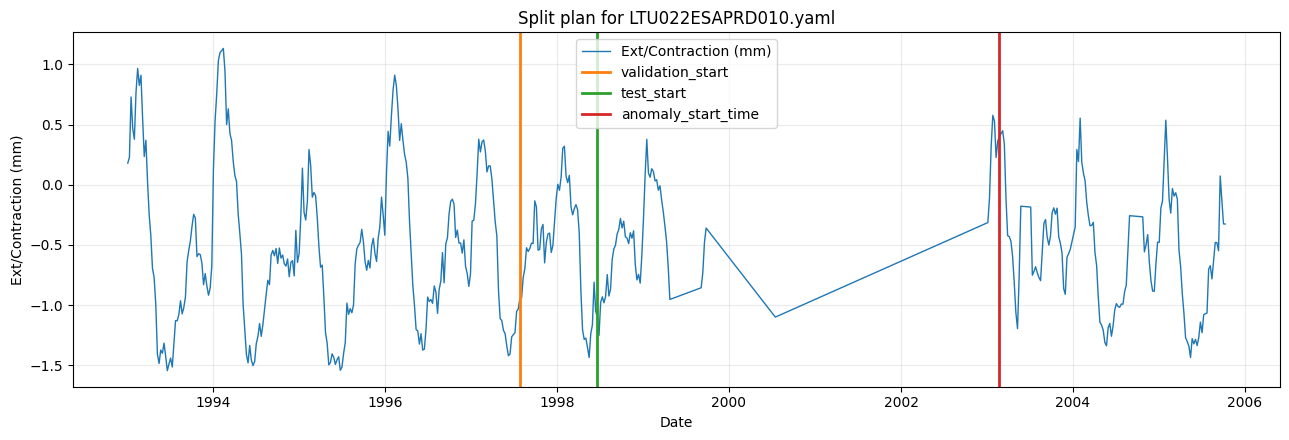

In [7]:
fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(series.index, series.values, color="tab:blue", linewidth=1.0, label=series.name)
ax.axvline(validation_start, color="tab:orange", linewidth=2, label="validation_start")
ax.axvline(test_start, color="tab:green", linewidth=2, label="test_start")
ax.axvline(anomaly_start_time, color="tab:red", linewidth=2, label="anomaly_start_time")
ax.set_title(f"Split plan for {config_file.name}")
ax.set_xlabel("Date")
ax.set_ylabel(series.name)
ax.grid(alpha=0.25)
ax.legend(loc="best")
plt.tight_layout()
plt.show()


In [8]:
if write_back_to_yaml:
    raw_text = config_file.read_text(encoding="utf-8")
    raw_text = replace_yaml_timestamp(raw_text, "validation_start", validation_start)
    raw_text = replace_yaml_timestamp(raw_text, "test_start", test_start)
    raw_text = replace_yaml_timestamp(raw_text, "anomaly_start_time", anomaly_start_time)
    config_file.write_text(raw_text, encoding="utf-8")
    print(f"Updated {config_file}")
else:
    print("write_back_to_yaml is False; no files were changed.")


write_back_to_yaml is False; no files were changed.
